In [28]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# =====================================================
# Synthetic data
# =====================================================

torch.manual_seed(42)
np.random.seed(42)

N = 5000
input_dim = 10
output_dim = 5

X = torch.randn(N, input_dim)

# True nonlinear function
Y = torch.zeros(N, output_dim)

Y[:, 0] = torch.sin(X[:, 0]) + 0.1 * torch.randn(N)
Y[:, 1] = X[:, 1]**2 + 0.2 * torch.randn(N)
Y[:, 2] = torch.exp(0.3 * X[:, 2]) + 0.15 * torch.randn(N)
Y[:, 3] = X[:, 3] * X[:, 4] + 0.3 * torch.randn(N)
Y[:, 4] = torch.cos(X[:, 5]) + 0.1 * torch.randn(N)

dataset = TensorDataset(X, Y)
loader = DataLoader(dataset, batch_size=128, shuffle=True)

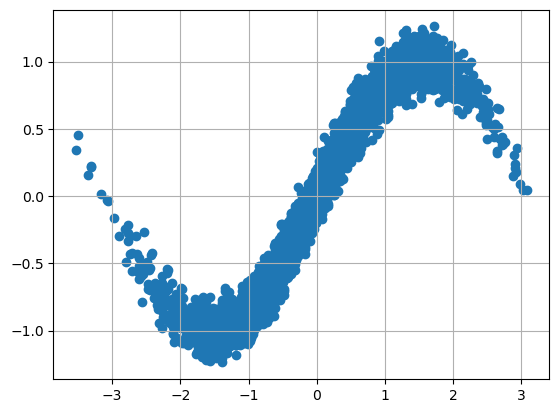

In [29]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], Y[:,0])
plt.grid(True)
plt.show()

In [30]:
# =====================================================
# Bayesian NN via MC Dropout
# =====================================================

class BayesianRegressor(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            # nn.Linear(128, 128),
            # nn.ReLU(),
            # nn.Dropout(0.1),

            # nn.Linear(128, 128),
            # nn.ReLU(),
            # nn.Dropout(0.1),

            # nn.Linear(128, 128),
            # nn.ReLU(),
            # nn.Dropout(0.1),

            # nn.Linear(128, 128),
            # nn.ReLU(),
            # nn.Dropout(0.1),
        )

        # Mean prediction
        self.mu_head = nn.Linear(256, output_dim)

        # Variance prediction
        self.log_var_head = nn.Linear(256, output_dim)

    def forward(self, x):

        h = self.net(x)

        mu = self.mu_head(h)

        # softplus avoids negative variance
        log_var = self.log_var_head(h)

        return mu, log_var


# =====================================================
# Gaussian NLL
# =====================================================

def gaussian_nll(y, mu, log_var):

    precision = torch.exp(-log_var)

    loss = 0.5 * (
        log_var +
        (y - mu) ** 2 * precision
    )

    return loss.mean()

In [31]:
# =====================================================
# Training
# =====================================================

device = "cuda" if torch.cuda.is_available() else "cpu"

model = BayesianRegressor(input_dim, output_dim).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

epochs = 50

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for xb, yb in loader:

        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        mu, log_var = model(xb)

        loss = gaussian_nll(yb, mu, log_var)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1:03d} | "
        f"Loss = {running_loss / len(loader):.4f}"
    )


# =====================================================
# MC Dropout inference
# =====================================================

def predict_mc(model, x, n_samples=100):

    model.train()  # KEEP DROPOUT ACTIVE

    mus = []
    vars_ = []

    with torch.no_grad():

        for _ in range(n_samples):

            mu, log_var = model(x)

            sigma2 = torch.exp(log_var)

            mus.append(mu)
            vars_.append(sigma2)

    mus = torch.stack(mus)
    vars_ = torch.stack(vars_)

    # Predictive mean
    mean = mus.mean(0)

    # Epistemic uncertainty
    epistemic = mus.var(0)

    # Aleatoric uncertainty
    aleatoric = vars_.mean(0)

    # Total uncertainty
    total_var = epistemic + aleatoric

    total_std = torch.sqrt(total_var)

    return mean, total_std, epistemic, aleatoric

Epoch 001 | Loss = 0.1802
Epoch 002 | Loss = -0.1014
Epoch 003 | Loss = -0.2099
Epoch 004 | Loss = -0.3275
Epoch 005 | Loss = -0.4547
Epoch 006 | Loss = -0.5805
Epoch 007 | Loss = -0.6820
Epoch 008 | Loss = -0.7499
Epoch 009 | Loss = -0.8157
Epoch 010 | Loss = -0.8578
Epoch 011 | Loss = -0.8855
Epoch 012 | Loss = -0.9113
Epoch 013 | Loss = -0.9268
Epoch 014 | Loss = -0.9566
Epoch 015 | Loss = -0.9659
Epoch 016 | Loss = -0.9907
Epoch 017 | Loss = -1.0073
Epoch 018 | Loss = -1.0322
Epoch 019 | Loss = -1.0338
Epoch 020 | Loss = -1.0525
Epoch 021 | Loss = -1.0632
Epoch 022 | Loss = -1.0641
Epoch 023 | Loss = -1.0820
Epoch 024 | Loss = -1.0858
Epoch 025 | Loss = -1.0994
Epoch 026 | Loss = -1.1099
Epoch 027 | Loss = -1.1083
Epoch 028 | Loss = -1.1013
Epoch 029 | Loss = -1.1143
Epoch 030 | Loss = -1.1203
Epoch 031 | Loss = -1.1340
Epoch 032 | Loss = -1.1437
Epoch 033 | Loss = -1.1396
Epoch 034 | Loss = -1.1426
Epoch 035 | Loss = -1.1491
Epoch 036 | Loss = -1.1560
Epoch 037 | Loss = -1.1602
Ep

In [32]:
# =====================================================
# Example prediction
# =====================================================

x_test = torch.randn(1, input_dim).to(device)

mean, std, epistemic, aleatoric = predict_mc(
    model,
    X.to(device),
    n_samples=100
)

print("\nPredicted means:")
print(mean.cpu().numpy())

print("\nPredicted std:")
print(std.cpu().numpy())

print("\nEpistemic variance:")
print(epistemic.cpu().numpy())

print("\nAleatoric variance:")
print(aleatoric.cpu().numpy())


Predicted means:
[[ 1.0760986   2.2461874   1.3390123  -1.3048583   0.30258358]
 [-0.3842744   2.0984862   0.8006332   0.4569419   0.7085305 ]
 [-0.6297184   1.0825394   1.2884524   2.2372527   0.33796492]
 ...
 [-0.8964504   0.29989094  0.7758409  -1.8532586   0.86731774]
 [ 0.3313944   1.0376803   1.1013173  -0.0791668   0.50646436]
 [-0.7684514   1.1293437   1.2327495   0.13847345  0.90737987]]

Predicted std:
[[0.29280585 0.41275126 0.19461341 0.4893236  0.16732113]
 [0.12009973 0.3676631  0.16523497 0.32033542 0.11247016]
 [0.14622627 0.31231183 0.17767684 0.48055464 0.1543749 ]
 ...
 [0.21464427 0.21151547 0.1830507  0.43249023 0.11828836]
 [0.11725634 0.25249013 0.16291672 0.3134562  0.14155252]
 [0.15411486 0.24628206 0.16018805 0.32776794 0.1070993 ]]

Epistemic variance:
[[0.02491968 0.06018272 0.00522719 0.05694776 0.00761654]
 [0.00348058 0.02211855 0.00110684 0.00639391 0.00189805]
 [0.00503668 0.01380694 0.00327997 0.05946812 0.0055796 ]
 ...
 [0.00812027 0.0019911  0.00

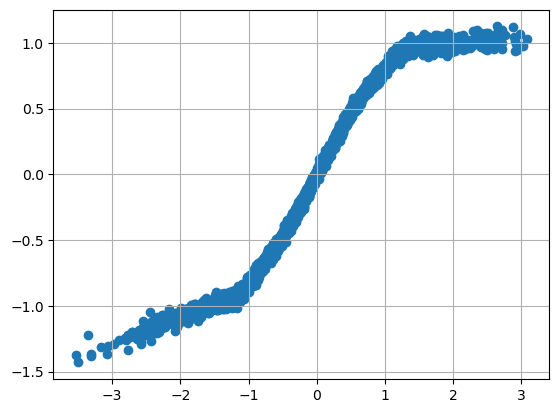

In [33]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0].cpu().numpy(), mean[:,0].cpu().numpy())
plt.grid(True)
plt.show()